**Install SHAP**

In [ ]:
!pip install -q shap

**Import the required libraries**

In [ ]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load the feature dataset**

In [ ]:
df = pd.read_csv("master_features.csv")

**Preview the dataset**

In [ ]:
df.head()

,Label,MolecularWeight,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,FP_0,FP_1,FP_2,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1,286.239,1.59282,4,6,115.06,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,154.253,2.50370,1,1,20.23,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,230.310,5.02060,0,0,0.00,2,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,108.140,1.70062,1,1,20.23,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,313.747,3.18870,0,6,58.40,7,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Separate predictors and target labels**

In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

**Split the dataset**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

**Train the XGBoost model**

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


**Mount Google Drive again**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Check whether the saved model exists**

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl"))

False


**Locate the saved XGBoost model**

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "XGBoost" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/Notebook5_XGBoost_Model.ipynb


**Unmount Google Drive**

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

**Mount Google Drive again**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Verify the model file**

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Notebook5_Output/XGBoost_model.pkl"))

False


**Import SHAP libraries**

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

**Create the SHAP explainer**

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_train.sample(200, random_state=42)

shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(200, 2054)


**Generate the SHAP summary plot**

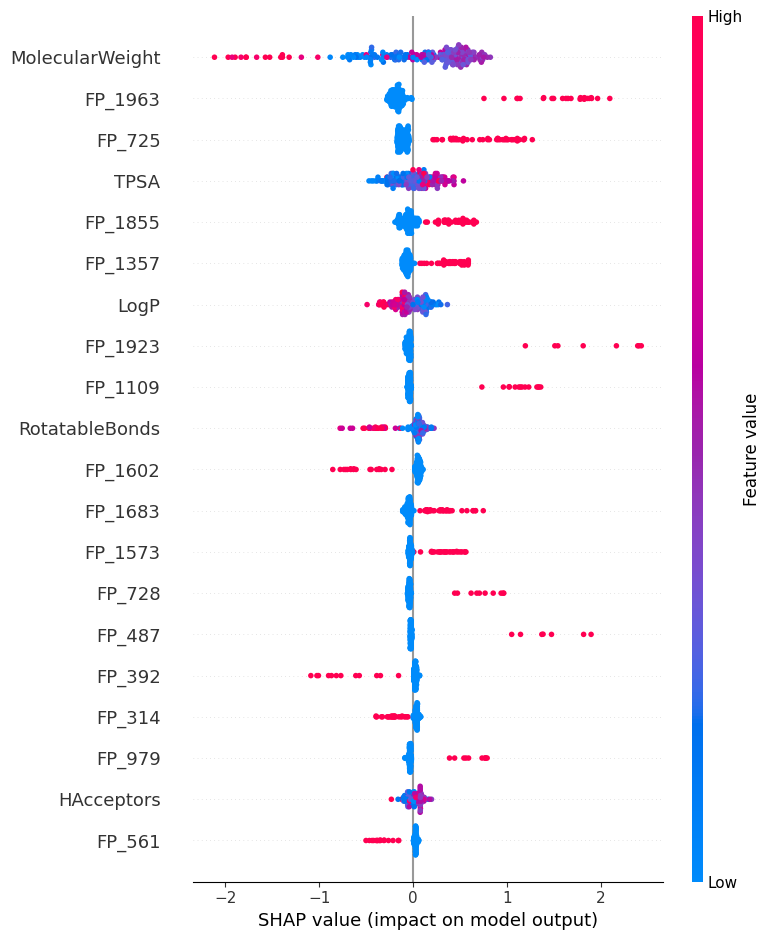

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20
)

**Generate the SHAP bar plot**

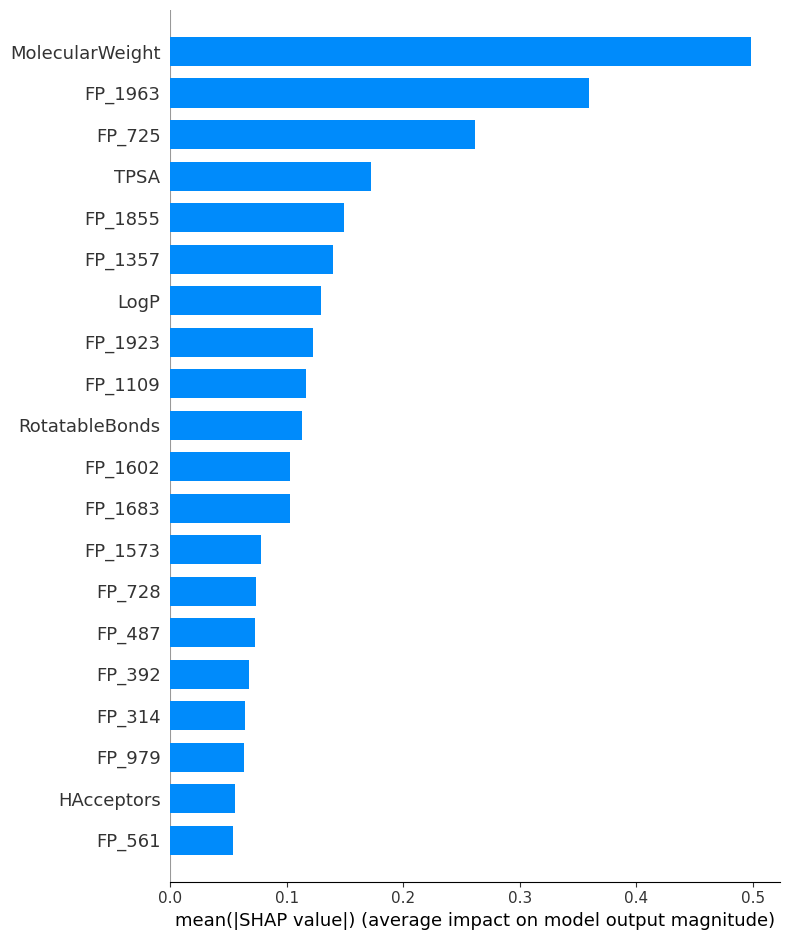

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display=20
)